1) Load dataset

In [547]:
import pandas as pd
import os

OUTPUT_DIR = "../outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)


In [548]:
df_path = "../data/processed/feature_engineered_with_SLM.csv"
df = pd.read_csv(df_path)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             1200 non-null   int64  
 1   customer_id                1200 non-null   int64  
 2   transaction_datetime       1200 non-null   object 
 3   country                    1200 non-null   object 
 4   channel                    1200 non-null   object 
 5   merchant_category          1200 non-null   object 
 6   amount                     1200 non-null   float64
 7   device_trust_score         1200 non-null   float64
 8   num_txn_24h_customer       1200 non-null   int64  
 9   previous_chargeback_count  1200 non-null   int64  
 10  is_fraud                   1200 non-null   int64  
 11  transaction_note           1200 non-null   object 
 12  slm_risk_score             1200 non-null   int64  
 13  slm_urgency                1200 non-null   objec

In [549]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)

print(missing[missing > 0].to_frame("Count of missing values"))

                     Count of missing values
txn_7d_count                            1200
prev_txn_time                            179
customer_std_amount                        1
amount_z_customer                          1


In [550]:
df.head()

,transaction_id,customer_id,transaction_datetime,country,channel,merchant_category,amount,device_trust_score,num_txn_24h_customer,previous_chargeback_count,...,txn_hour_count,txn_dayofweek_count,customer_mean_amount,customer_std_amount,amount_z_customer,is_risky_country,low_device_trust,high_amount_z,composite_risk_score,urgency_numeric
0,998,1000,2022-10-05 15:13:00,US,mobile_app,luxury,672.47,23.0,2,3,...,1,2,1931.283333,1662.07937,-0.757373,0,1,0,7.333333,2
1,953,1000,2023-02-05 06:18:18,US,web,gaming,2593.31,84.0,0,0,...,1,2,1931.283333,1662.07937,0.398312,0,0,0,3.555556,2
2,94,1000,2023-03-23 18:04:02,US,pos_terminal,electronics,302.22,70.0,3,1,...,1,2,1931.283333,1662.07937,-0.980136,0,0,0,4.000000,2
3,457,1000,2023-04-05 00:14:27,US,mobile_app,gaming,4395.07,24.0,0,2,...,1,2,1931.283333,1662.07937,1.482352,0,1,0,7.333333,2
4,1199,1000,2023-07-13 02:02:46,US,mobile_app,luxury,579.99,23.0,1,0,...,1,2,1931.283333,1662.07937,-0.813014,0,1,0,5.555556,0


2. Define target variable & features

In [551]:
target_col = 'is_fraud'   
drop_cols = ['transaction_id', 'customer_id', 'transaction_datetime', 
             'prev_txn_time', 'transaction_note', 'txn_7d_count', 'is_fraud']

x = df.drop(columns=drop_cols)
y = df[target_col].astype(int)


In [552]:
# numerical and categorical columns
categorical_cols = [col for col in x.columns if x[col].dtype == 'object']
numeric_cols = [col for col in x.columns if col not in categorical_cols]

print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)

Categorical features: ['country', 'channel', 'merchant_category', 'slm_urgency', 'slm_anomaly_category']
Numeric features: ['amount', 'device_trust_score', 'num_txn_24h_customer', 'previous_chargeback_count', 'slm_risk_score', 'txn_hour', 'txn_dayofweek', 'txn_week', 'is_weekend', 'is_night', 'txn_gap_minutes', 'txn_hour_count', 'txn_dayofweek_count', 'customer_mean_amount', 'customer_std_amount', 'amount_z_customer', 'is_risky_country', 'low_device_trust', 'high_amount_z', 'composite_risk_score', 'urgency_numeric']


3. Train-test split data

In [553]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

4. Preprocess data 

In [554]:
# Simple imputation for both, one-hot encoding for categorical data and scaling for numerical data
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_tf, numeric_cols),
        ("cat", categorical_tf, categorical_cols)
    ])

5. Data modelling using Logistic Regression

In [555]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
LR_classifier = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

LR_classifier.fit(x_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [556]:
# Prediction
y_pred = LR_classifier.predict(x_test)
y_proba = LR_classifier.predict_proba(x_test)[:,1]

6. Model evaluation

In [557]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, average_precision_score, classification_report

metrics = {
    "model": "LogisticRegression",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba),
}

pd.DataFrame([metrics])

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogisticRegression,0.633333,0.081395,0.4375,0.137255,0.544643,0.09363


In [558]:
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))


Classification report:
              precision    recall  f1-score   support

           0     0.9416    0.6473    0.7672       224
           1     0.0814    0.4375    0.1373        16

    accuracy                         0.6333       240
   macro avg     0.5115    0.5424    0.4522       240
weighted avg     0.8842    0.6333    0.7252       240



7. Hyperparameter tuning

In [559]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'classifier__penalty': ['l1','l2','elasticnet', None],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear','saga','lbfgs','sag']
}

# Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch on the pipeline 
grid = GridSearchCV(
    LR_classifier,  
    param_grid=param_grid,
    cv=cv,
    scoring='f1',   
    verbose=2,
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)


Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best score: 0.17502133417616497


c:\Users\ASUS\Documents\aisyah\VSC\WIE3007-G14-GroupProject\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
120 fits failed out of a total of 320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ASUS\Documents\aisyah\VSC\WIE3007-G14-GroupProject\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ASUS\Documents\aisyah\VSC\WIE3007-G14-GroupProject\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

8. Tuned Logistic Regression evaluation

In [560]:
tuned_LR_classifier = grid.best_estimator_

y_pred_tuned = tuned_LR_classifier.predict(x_test)
y_proba_tuned = tuned_LR_classifier.predict_proba(x_test)[:,1]

In [561]:
tuned_metrics = {
    "model": "LogisticRegressionTuned",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_tuned),
    "pr_auc": average_precision_score(y_test, y_proba_tuned)
}

pd.DataFrame([tuned_metrics])


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogisticRegressionTuned,0.641667,0.093023,0.5,0.156863,0.538783,0.076613


In [562]:
print("\nClassification report:")
print(classification_report(y_test, y_pred_tuned, digits=4))


Classification report:
              precision    recall  f1-score   support

           0     0.9481    0.6518    0.7725       224
           1     0.0930    0.5000    0.1569        16

    accuracy                         0.6417       240
   macro avg     0.5205    0.5759    0.4647       240
weighted avg     0.8911    0.6417    0.7314       240



In [563]:
comparison = pd.DataFrame([metrics, tuned_metrics])
comparison

comparison.to_csv(
    os.path.join(TAB_DIR, "logReg_metrics.csv"),
    index=False
)

print("Saved table to:", os.path.join(TAB_DIR, "lr_metrics_comparison.csv"))


Saved table to: ../outputs\tables\lr_metrics_comparison.csv


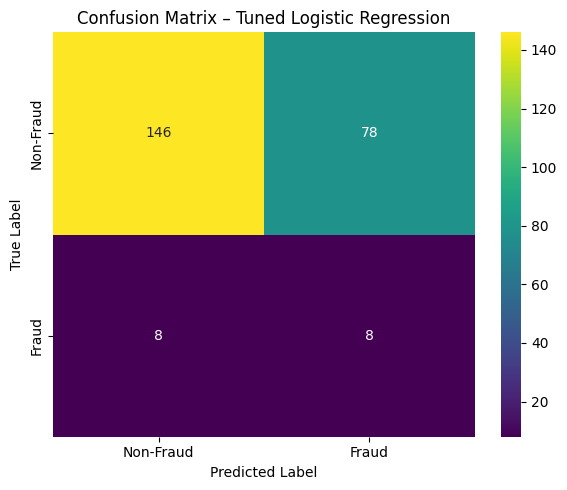

In [564]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Tuned Logistic Regression")
plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "logReg_tuned_confusion_matrix.png"),
    dpi=200
)

plt.show()


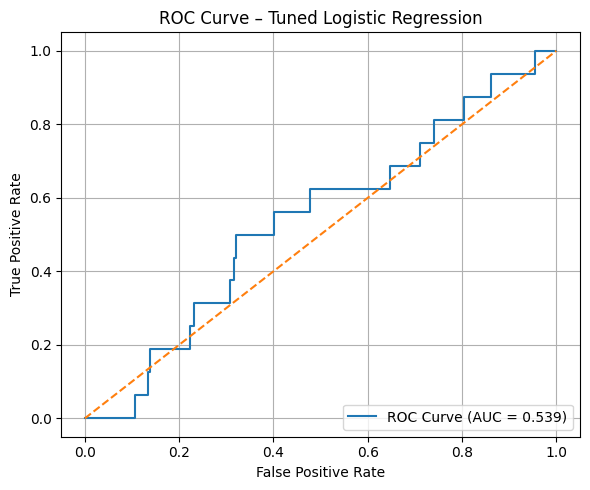

In [565]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba_tuned)
roc_auc = roc_auc_score(y_test, y_proba_tuned)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Tuned Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "logReg_tuned_roc_curve.png"),
    dpi=200
)

plt.show()


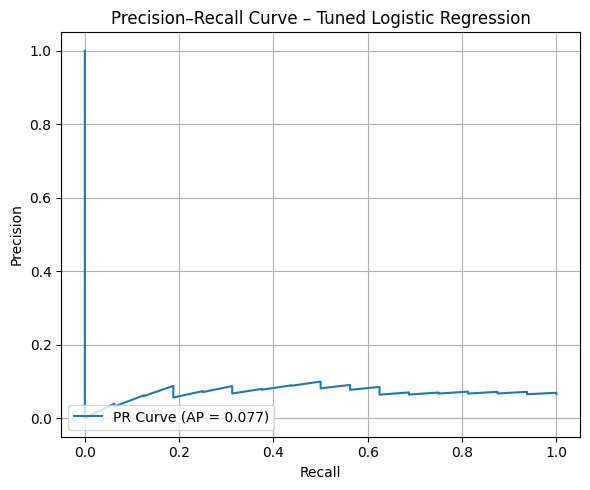

In [566]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tuned)
pr_auc = average_precision_score(y_test, y_proba_tuned)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR Curve (AP = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Tuned Logistic Regression")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "logReg_tuned_pr_curve.png"),
    dpi=200
)

plt.show()
